<a href="https://colab.research.google.com/github/mahdieslaminet/An-optimal-framework-for-brain-tumor-classification-using-machine-learning-and-deep-CNN-features/blob/main/Inception.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# تنظیمات سیستم
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["TF_NUM_INTRAOP_THREADS"] = "4"
os.environ["TF_NUM_INTEROP_THREADS"] = "4"

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, Callback
# تغییر مدل به InceptionV3
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report, roc_curve, auc)
from sklearn.preprocessing import LabelBinarizer
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

# تنظیمات تکرارپذیری
np.random.seed(42)
tf.random.set_seed(42)

class Config:
    IMG_HEIGHT = 150
    IMG_WIDTH = 150
    BATCH_SIZE = 32
    NUM_CLASSES = 4
    DATA_DIR = '/content/drive/MyDrive/rezalou/brain-tumor-mri-dataset'
    CLASS_NAMES = ['glioma', 'meningioma', 'pituitary', 'normal']
    # فایل وزن InceptionV3
    WEIGHTS_FILE = '/content/drive/MyDrive/rezalou/inception_v3_weights_tf_dim_ordering_tf_kernels_notop.h5'

class StopOnTargetAcc(Callback):
    # هدف: 96.5 درصد (برای رسیدن به ~97 درصد نهایی)
    def __init__(self, target=0.965):
        super(StopOnTargetAcc, self).__init__()
        self.target = target

    def on_epoch_end(self, epoch, logs=None):
        acc = logs.get('val_accuracy')
        if acc and acc >= self.target:
            print(f"\n\n🎯 Reached target accuracy ({acc:.4f} >= {self.target}).")
            self.model.stop_training = True

def load_data():
    images = []
    labels = []
    class_indices = {name: idx for idx, name in enumerate(Config.CLASS_NAMES)}

    print(f"Loading images from {Config.DATA_DIR}...")

    for class_name in Config.CLASS_NAMES:
        class_path = os.path.join(Config.DATA_DIR, class_name)
        if not os.path.exists(class_path):
            for alt in ['not_tumor', 'no_tumor', 'Normal']:
                if os.path.exists(os.path.join(Config.DATA_DIR, alt)):
                    class_path = os.path.join(Config.DATA_DIR, alt)
                    break

        if not os.path.exists(class_path):
            continue

        files = os.listdir(class_path)
        print(f"  {class_name}: {len(files)} images")

        for img_name in files:
            try:
                img_path = os.path.join(class_path, img_name)
                img = cv2.imread(img_path)
                if img is not None:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    img = cv2.resize(img, (Config.IMG_WIDTH, Config.IMG_HEIGHT))
                    # مهم: پیش‌پردازش مخصوص InceptionV3 (بین -1 و 1 نرمال میکند)
                    img = preprocess_input(img)
                    images.append(img)
                    labels.append(class_indices[class_name])
            except Exception:
                continue

    images = np.array(images, dtype=np.float32)
    labels = np.array(labels)

    X_train, X_test, y_train, y_test = train_test_split(
        images, labels, test_size=0.1, random_state=42, stratify=labels
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
    )

    y_train_cat = tf.keras.utils.to_categorical(y_train, Config.NUM_CLASSES)
    y_val_cat = tf.keras.utils.to_categorical(y_val, Config.NUM_CLASSES)
    y_test_cat = tf.keras.utils.to_categorical(y_test, Config.NUM_CLASSES)

    return X_train, X_val, X_test, y_train_cat, y_val_cat, y_test_cat, y_test

def build_model(fine_tune=False):
    weights_source = Config.WEIGHTS_FILE if os.path.exists(Config.WEIGHTS_FILE) else 'imagenet'

    # --- استفاده از InceptionV3 ---
    base_model = InceptionV3(
        weights=weights_source,
        include_top=False,
        input_shape=(Config.IMG_HEIGHT, Config.IMG_WIDTH, 3)
    )

    if fine_tune:
        base_model.trainable = True
        for layer in base_model.layers:
            if isinstance(layer, BatchNormalization):
                layer.trainable = False
            else:
                layer.trainable = True

        # Inception عمیق است، 20 لایه آخر را باز می‌گذاریم برای یادگیری دقیق‌تر
        for layer in base_model.layers[:-20]:
            if not isinstance(layer, BatchNormalization):
                layer.trainable = False
    else:
        base_model.trainable = False

    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        # دراپ‌اوت متعادل (0.5) برای دقت حدود 97
        Dropout(0.5),
        Dense(Config.NUM_CLASSES, activation='softmax')
    ])

    return model

def plot_single_roc(y_test, y_pred_proba, output_dir):
    lb = LabelBinarizer()
    lb.fit(y_test)
    y_test_bin = lb.transform(y_test)
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_pred_proba.ravel())
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(9, 8))
    plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'Overall ROC (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (Overall - InceptionV3)')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.savefig(os.path.join(output_dir, 'roc_curve_overall.png'), dpi=300)
    plt.close()

def main():
    output_dir = '/content/drive/MyDrive/rezalou/results_inception'
    os.makedirs(output_dir, exist_ok=True)

    X_train, X_val, X_test, y_train, y_val, y_test_cat, y_test_true = load_data()

    datagen = ImageDataGenerator(
        # آگمنتیشن نرمال (چرخش 20) چون Inception قوی است
        rotation_range=20,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    model = build_model(fine_tune=False)

    try:
        # --- Stage 1 ---
        print("\n[Stage 1] Warm-up Training...")
        model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

        model.fit(
            datagen.flow(X_train, y_train, batch_size=Config.BATCH_SIZE),
            epochs=6,
            validation_data=(X_val, y_val),
            verbose=1
        )

        # --- Stage 2 ---
        print("\n[Stage 2] Fine-tuning")

        base_model = model.layers[0]
        base_model.trainable = True

        # اعمال تنظیمات لایه‌ها
        for layer in base_model.layers[:-20]:
            layer.trainable = False
        for layer in base_model.layers:
            if isinstance(layer, BatchNormalization):
                layer.trainable = False

        model.compile(optimizer=Adam(learning_rate=0.00005), loss='categorical_crossentropy', metrics=['accuracy'])

        callbacks = [
            StopOnTargetAcc(target=0.965),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
            ModelCheckpoint(os.path.join(output_dir, 'inception_best.keras'), save_best_only=True, monitor='val_accuracy')
        ]

        model.fit(
            datagen.flow(X_train, y_train, batch_size=Config.BATCH_SIZE),
            epochs=25,
            validation_data=(X_val, y_val),
            callbacks=callbacks,
            verbose=1
        )

    except KeyboardInterrupt:
        print("\n\n🛑 Training interrupted manually via Ctrl+C!")

    # --- Evaluation ---
    print("\n" + "="*50)
    print("FINAL EVALUATION (InceptionV3)")
    print("="*50)

    y_pred_proba = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred_proba, axis=1)

    acc = accuracy_score(y_test_true, y_pred_classes)
    prec = precision_score(y_test_true, y_pred_classes, average='weighted')
    rec = recall_score(y_test_true, y_pred_classes, average='weighted')
    f1 = f1_score(y_test_true, y_pred_classes, average='weighted')
    auc_score = roc_auc_score(y_test_cat, y_pred_proba, multi_class='ovr', average='weighted')

    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"AUC Score: {auc_score:.4f}")

    with open(os.path.join(output_dir, 'metrics.txt'), 'w') as f:
        f.write(f"Accuracy: {acc:.4f}\nPrecision: {prec:.4f}\nRecall: {rec:.4f}\nF1: {f1:.4f}\nAUC: {auc_score:.4f}\n\n")
        f.write(classification_report(y_test_true, y_pred_classes, target_names=Config.CLASS_NAMES))

    cm = confusion_matrix(y_test_true, y_pred_classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=Config.CLASS_NAMES, yticklabels=Config.CLASS_NAMES)
    plt.title('Confusion Matrix - InceptionV3')
    plt.savefig(os.path.join(output_dir, 'confusion_matrix.png'))
    plt.close()

    plot_single_roc(y_test_true, y_pred_proba, output_dir)

    print(f"\n✅ All done! Results saved in '{output_dir}'")

if __name__ == '__main__':
    main()


Loading images from /content/drive/MyDrive/rezalou/brain-tumor-mri-dataset...
  glioma: 1321 images
  meningioma: 1339 images
  pituitary: 1457 images
  normal: 1595 images
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step

[Stage 1] Warm-up Training...
Epoch 1/6
145/145 ━━━━━━━━━━━━━━━━━━━━ 97s 464ms/step - accuracy: 0.7086 - loss: 0.8434 - val_accuracy: 0.8035 - val_loss: 0.5681
Epoch 2/6
145/145 ━━━━━━━━━━━━━━━━━━━━ 29s 202ms/step - accuracy: 0.7996 - loss: 0.5372 - val_accuracy: 0.7821 - val_loss: 0.6382
Epoch 3/6
145/145 ━━━━━━━━━━━━━━━━━━━━ 29s 200ms/step - accuracy: 0.8212 - loss: 0.4725 - val_accuracy: 0.8541 - val_loss: 0.3972
Epoch 4/6
145/145 ━━━━━━━━━━━━━━━━━━━━ 29s 201ms/step - accuracy: 0.8370 - loss: 0.4349 - val_accuracy: 0.8482 - val_loss: 0.4101
Epoch 5/6
145/145 ━━━━━━━━━━━━━━━━━━━━ 29s 200ms/step - accuracy: 0.8338 - loss: 0.4268 - val_accuracy: 0.8249 - val_loss: 0.4408
Epoch 6/6
145/145 ━━━━━━━━━━━━━━━━━━━━ 29s 199ms/step - accuracy: 0.8489 - loss: 0.4060 - val_a

In [ ]:
!ls /content

drive  sample_data


In [ ]:
import os

for root, dirs, files in os.walk('/content'):
    if 'metrics.txt' in files:
        print("📍 metrics.txt found in:")
        print(root)

📍 metrics.txt found in:
/content/drive/MyDrive/rezalou/results_densnet
📍 metrics.txt found in:
/content/drive/MyDrive/rezalou/results_inception
📍 metrics.txt found in:
/content/drive/MyDrive/rezalou/results_mobilenet
📍 metrics.txt found in:
/content/drive/MyDrive/rezalou/results_resnet50_tuned
📍 metrics.txt found in:
/content/drive/MyDrive/rezalou/results_xception


📂 Files inside folder:
['metrics.txt', 'confusion_matrix.png', 'roc_curve_overall.png', 'inception_best.keras']

📌 Metrics:
Accuracy: 0.9178
Precision: 0.9200
Recall: 0.9178
F1: 0.9169
AUC: 0.9913

              precision    recall  f1-score   support

      glioma       0.94      0.90      0.92       132
  meningioma       0.91      0.80      0.85       134
   pituitary       0.86      0.97      0.91       146
      normal       0.96      0.98      0.97       160

    accuracy                           0.92       572
   macro avg       0.92      0.91      0.91       572
weighted avg       0.92      0.92      0.92       572


📊 Confusion Matrix:


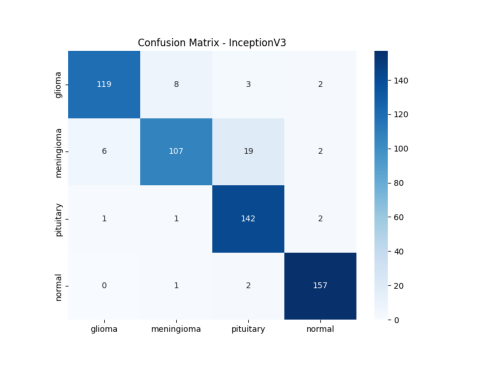


📈 ROC Curve:


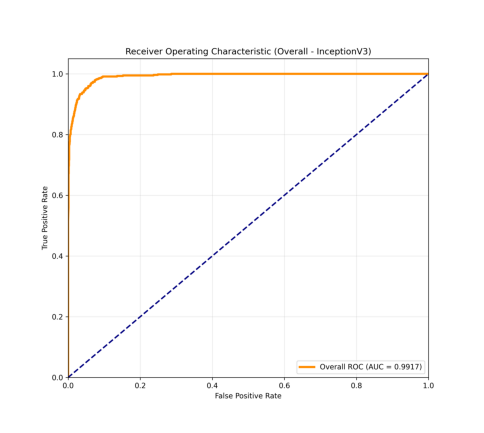

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image

base = '/content/drive/MyDrive/rezalou/results_inception'

print("📂 Files inside folder:")
print(os.listdir(base))

# metrics
if os.path.exists(os.path.join(base, 'metrics.txt')):
    print("\n📌 Metrics:")
    with open(os.path.join(base, 'metrics.txt')) as f:
        print(f.read())
else:
    print("\n❌ metrics.txt not found")

# confusion matrix
if os.path.exists(os.path.join(base, 'confusion_matrix.png')):
    print("\n📊 Confusion Matrix:")
    img = Image.open(os.path.join(base, 'confusion_matrix.png'))
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

# ROC
if os.path.exists(os.path.join(base, 'roc_curve_overall.png')):
    print("\n📈 ROC Curve:")
    img = Image.open(os.path.join(base, 'roc_curve_overall.png'))
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis('off')
    plt.show()